In [2]:
import numpy as np
import pandas as pd
np.random.seed(42)
n = 1800  
household_size = np.random.randint(1, 8, n)
seasonal_index = np.round(np.random.uniform(0.7, 1.6, n), 2)
garden_area = np.random.randint(0, 150, n)
income_level = np.random.randint(20000, 150000, n)
bathrooms = np.random.randint(1, 5, n)
appliances = np.random.randint(5, 25, n)
rainfall = np.round(np.random.uniform(0, 200, n), 2)  # mm
temperature = np.round(np.random.uniform(10, 40, n), 2)  # °C
water_price = np.round(np.random.uniform(0.5, 2.5, n), 2)
daily_liters_used = (
    50 +
    (household_size * 80) +
    (garden_area * 2.2) +
    (seasonal_index * 100) +
    (bathrooms * 30) +
    (appliances * 5) +
    (temperature * 10) -
    (rainfall * 3) -
    (water_price * 40) +
    np.random.normal(0, 60, n)
)
daily_liters_used = np.round(daily_liters_used, 0)
df = pd.DataFrame({
    "Household_Size": household_size,
    "Seasonal_Index": seasonal_index,
    "Garden_Area": garden_area,
    "Income_Level": income_level,
    "Bathrooms": bathrooms,
    "Appliances_Count": appliances,
    "Rainfall": rainfall,
    "Temperature": temperature,
    "Water_Price_Index": water_price,
    "Daily_Liters_Used": daily_liters_used
})
for col in df.columns:
    df.loc[np.random.choice(df.index, 60, replace=False), col] = np.nan
df = pd.concat([df, df.sample(100)], ignore_index=True)
df.loc[np.random.choice(df.index, 30), "Daily_Liters_Used"] *= 2
df.loc[np.random.choice(df.index, 20), "Garden_Area"] = 40
df = df.sample(frac=1).reset_index(drop=True)
df.to_csv("feature_raw_dataset.csv", index=False)

In [4]:
df=pd.read_csv(r"C:\Users\Acer\feature_raw_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_Size     1837 non-null   float64
 1   Seasonal_Index     1838 non-null   float64
 2   Garden_Area        1840 non-null   float64
 3   Income_Level       1837 non-null   float64
 4   Bathrooms          1834 non-null   float64
 5   Appliances_Count   1838 non-null   float64
 6   Rainfall           1838 non-null   float64
 7   Temperature        1836 non-null   float64
 8   Water_Price_Index  1836 non-null   float64
 9   Daily_Liters_Used  1838 non-null   float64
dtypes: float64(10)
memory usage: 148.6 KB


In [6]:
df.describe()

,Household_Size,Seasonal_Index,Garden_Area,Income_Level,Bathrooms,Appliances_Count,Rainfall,Temperature,Water_Price_Index,Daily_Liters_Used
count,1837.000000,1838.000000,1840.000000,1837.000000,1834.000000,1838.000000,1838.000000,1836.000000,1836.000000,1838.000000
mean,3.962439,1.149478,76.080978,84205.928688,2.452017,14.593036,100.564788,24.942190,1.510387,693.683896
std,2.007395,0.261918,43.256025,37910.761821,1.109469,5.767005,57.800651,8.682556,0.574343,301.729769
min,1.000000,0.700000,0.000000,20060.000000,1.000000,5.000000,0.270000,10.010000,0.500000,-95.000000
25%,2.000000,0.920000,39.000000,50607.000000,1.000000,10.000000,51.857500,17.680000,1.020000,488.250000
50%,4.000000,1.150000,76.000000,84952.000000,2.000000,15.000000,101.945000,24.760000,1.540000,692.000000
75%,6.000000,1.380000,114.000000,117975.000000,3.000000,20.000000,151.795000,32.282500,2.000000,901.000000
max,7.000000,1.600000,149.000000,149949.000000,4.000000,24.000000,199.950000,39.990000,2.500000,2092.000000


In [7]:
df.isnull().sum()

Household_Size       63
Seasonal_Index       62
Garden_Area          60
Income_Level         63
Bathrooms            66
Appliances_Count     62
Rainfall             62
Temperature          64
Water_Price_Index    64
Daily_Liters_Used    62
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(96)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.loc[df["Household_Size"] < 0, "Household_Size"] = np.nan
df.loc[df["Garden_Area"] < 0, "Garden_Area"] = np.nan
df.loc[df["Bathrooms"] < 0, "Bathrooms"] = np.nan

In [12]:
# Median for discrete / skewed
df["Household_Size"].fillna(df["Household_Size"].median(), inplace=True)
df["Garden_Area"].fillna(df["Garden_Area"].median(), inplace=True)
df["Bathrooms"].fillna(df["Bathrooms"].median(), inplace=True)
df["Appliances_Count"].fillna(df["Appliances_Count"].median(), inplace=True)

In [13]:
df["Seasonal_Index"].fillna(df["Seasonal_Index"].mean(), inplace=True)
df["Income_Level"].fillna(df["Income_Level"].mean(), inplace=True)
df["Rainfall"].fillna(df["Rainfall"].mean(), inplace=True)
df["Temperature"].fillna(df["Temperature"].mean(), inplace=True)
df["Water_Price_Index"].fillna(df["Water_Price_Index"].mean(), inplace=True)
df["Daily_Liters_Used"].fillna(df["Daily_Liters_Used"].mean(), inplace=True)

In [15]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outlier_mask_iqr = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
print("Outliers per column:\n", outlier_mask_iqr.sum())

Outliers per column:
 Household_Size        0
Seasonal_Index        0
Garden_Area           0
Income_Level          0
Bathrooms             0
Appliances_Count      0
Rainfall              0
Temperature           0
Water_Price_Index     0
Daily_Liters_Used    10
dtype: int64


In [17]:
df = df[~outlier_mask_iqr.any(axis=1)]
df.reset_index(drop=True, inplace=True)

In [18]:
X = df.drop("Daily_Liters_Used", axis=1)
y = df["Daily_Liters_Used"]

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1435, 9)
X_test: (359, 9)
y_train: (1435,)
y_test: (359,)


In [23]:
from sklearn.cluster import KMeans

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
household = int(input("Household Size: "))
season = float(input("Seasonal Index: "))
garden = int(input("Garden Area: "))
income = float(input("Income Level: "))
bathrooms = int(input("Bathrooms: "))
appliances = int(input("Appliances Count: "))
rainfall = float(input("Rainfall: "))
temperature = float(input("Temperature: "))
price = float(input("Water Price Index: "))
input_data = pd.DataFrame([[household, season, garden, income, bathrooms,
                            appliances, rainfall, temperature, price]],
                          columns=X.columns)
input_scaled = scaler.transform(input_data)
cluster = kmeans.predict(input_scaled)

print("Assigned Cluster:", cluster[0])

Household Size:  2000
Seasonal Index:  1.5
Garden Area:  200
Income Level:  25000
Bathrooms:  2
Appliances Count:  1
Rainfall:  55
Temperature:  23
Water Price Index:  1.2


Assigned Cluster: 2


C:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


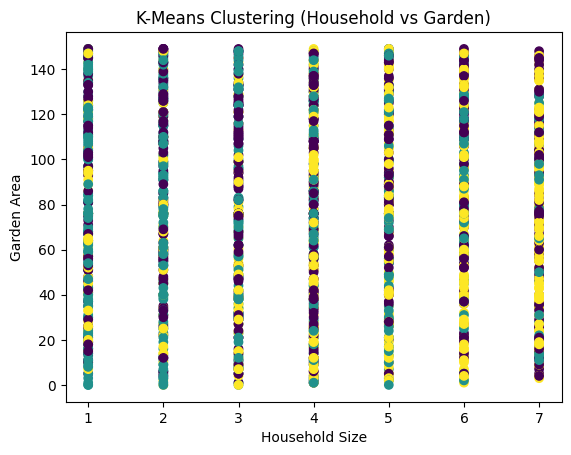

In [27]:
import matplotlib.pyplot as plt
plt.scatter(df["Household_Size"], df["Garden_Area"], c=df["Cluster"])
plt.xlabel("Household Size")
plt.ylabel("Garden Area")
plt.title("K-Means Clustering (Household vs Garden)")
plt.show()

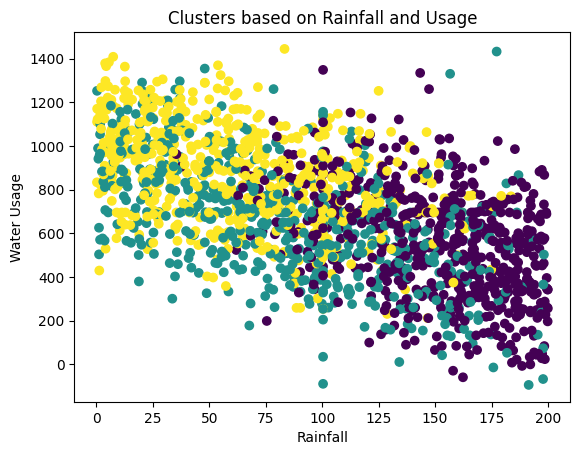

In [28]:
plt.scatter(df["Rainfall"], df["Daily_Liters_Used"], c=df["Cluster"])
plt.xlabel("Rainfall")
plt.ylabel("Water Usage")
plt.title("Clusters based on Rainfall and Usage")
plt.show()

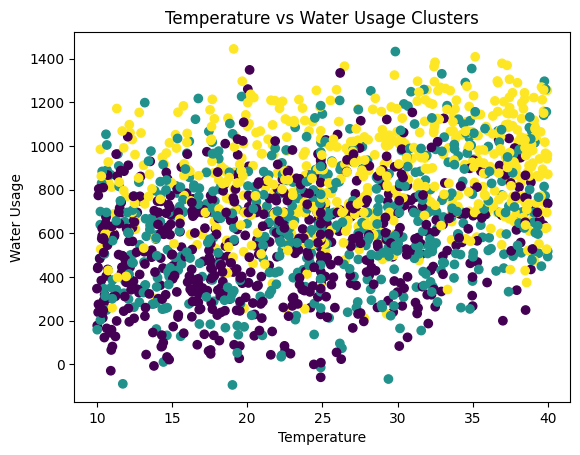

In [29]:
plt.scatter(df["Temperature"], df["Daily_Liters_Used"], c=df["Cluster"])
plt.xlabel("Temperature")
plt.ylabel("Water Usage")
plt.title("Temperature vs Water Usage Clusters")
plt.show()

In [30]:
df.head()

,Household_Size,Seasonal_Index,Garden_Area,Income_Level,Bathrooms,Appliances_Count,Rainfall,Temperature,Water_Price_Index,Daily_Liters_Used,Cluster
0,6.0,1.09,36.0,29045.000000,3.0,11.0,190.82,17.57,2.07,388.0,0
1,5.0,0.97,67.0,21299.000000,2.0,23.0,47.36,24.93,1.59,909.0,2
2,7.0,1.57,43.0,84169.397362,1.0,15.0,110.43,19.76,1.58,773.0,2
3,5.0,1.59,46.0,49553.000000,1.0,15.0,61.54,24.80,0.64,775.0,2
4,5.0,1.46,90.0,49831.000000,1.0,10.0,185.26,14.25,1.35,486.0,0


In [41]:
df.to_csv("cleaned_dataset.csv", index=False)

In [32]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.07543122655339186


In [37]:
features = ["Household_Size", "Garden_Area", "Income_Level", "Bathrooms"]
X_imp = df[features]
scaler = StandardScaler()
X_scaled_imp = scaler.fit_transform(X_imp)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled_imp)
df["Cluster"] = kmeans.predict(X_scaled_imp)
household = int(input("Enter Household Size: "))
garden = int(input("Enter Garden Area: "))
income = float(input("Enter Income Level: "))
bathrooms = int(input("Enter Number of Bathrooms: "))
import pandas as pd
input_data = pd.DataFrame(
    [[household, garden,income, bathrooms]],
    columns=features
)
input_scaled = scaler.transform(input_data)
cluster = kmeans.predict(input_scaled)
print("Assigned Cluster:", cluster[0])
print(df.groupby("Cluster")[features].mean())

Enter Household Size:  3
Enter Garden Area:  100
Enter Income Level:  25000
Enter Number of Bathrooms:  1


Assigned Cluster: 1
         Household_Size  Garden_Area  Income_Level  Bathrooms
Cluster                                                      
0              5.195531    77.240223  83840.806615   3.527002
1              5.132901    74.863857  85167.149023   1.473258
2              1.782812    76.335938  83452.413659   2.467188


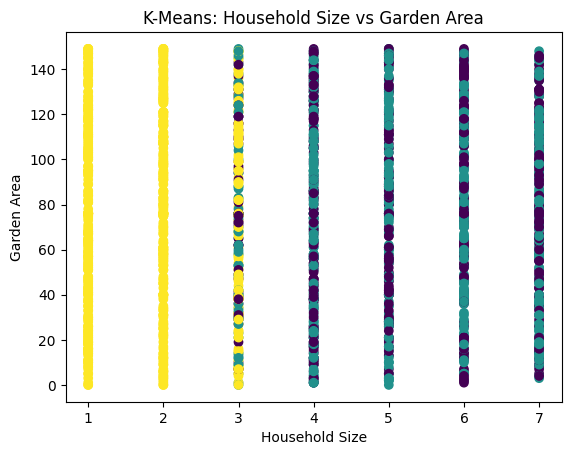

In [38]:
plt.scatter(df["Household_Size"], df["Garden_Area"], c=df["Cluster"])
plt.xlabel("Household Size")
plt.ylabel("Garden Area")
plt.title("K-Means: Household Size vs Garden Area")
plt.show()

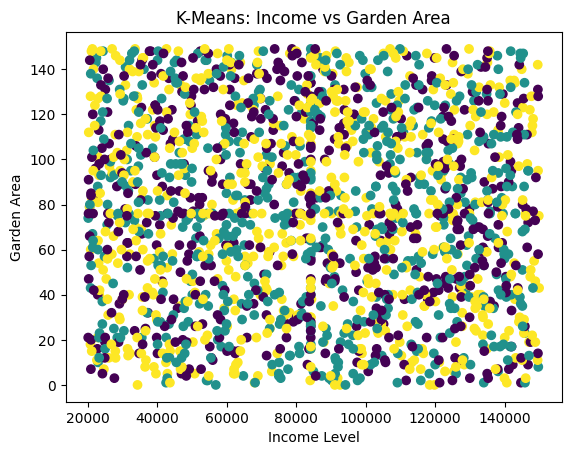

In [39]:
plt.scatter(df["Income_Level"], df["Garden_Area"], c=df["Cluster"])
plt.xlabel("Income Level")
plt.ylabel("Garden Area")
plt.title("K-Means: Income vs Garden Area")
plt.show()

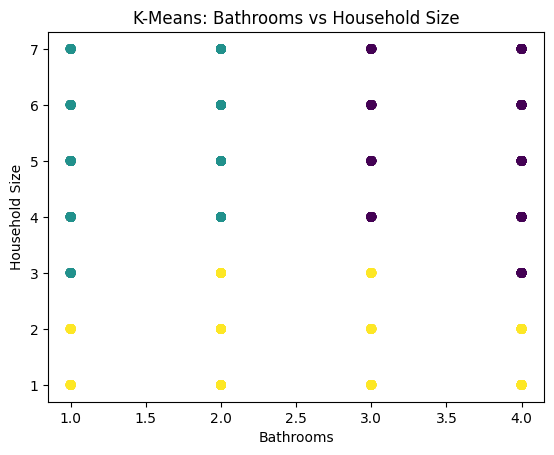

In [40]:
plt.scatter(df["Bathrooms"], df["Household_Size"], c=df["Cluster"])
plt.xlabel("Bathrooms")
plt.ylabel("Household Size")
plt.title("K-Means: Bathrooms vs Household Size")
plt.show()